GRU CLASSIFIER MODEL USING OHLCV DATA

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test Accuracy: 0.5490


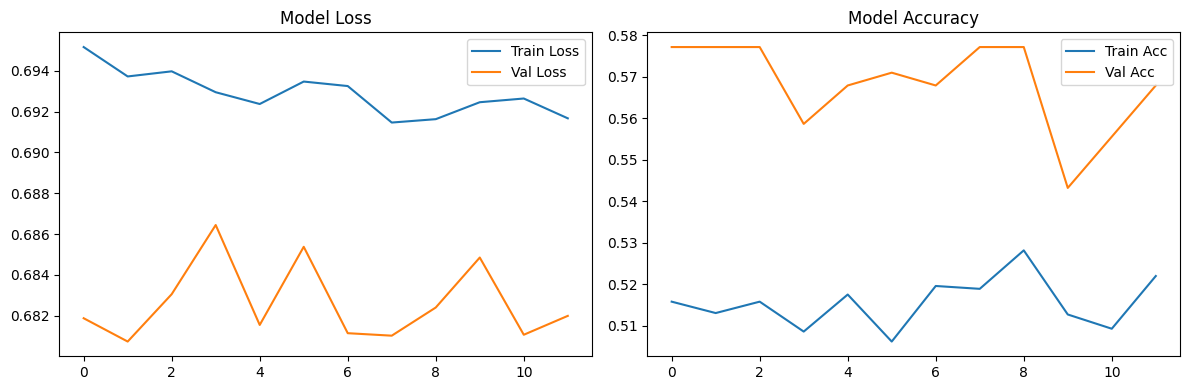

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

# 1. Load data
df = pd.read_csv('NIFTY50.csv')

# 2. Drop empty columns (all NaNs)
df = df.dropna(axis=1, how='all')

# 3. Data Cleaning
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Drop rows with any NaN in OHLCV
df = df.dropna()

# 4. Feature Engineering & Target Definition
df['Prev_Close'] = df['Close'].shift(1)
df['Price_Diff'] = df['Close'] - df['Prev_Close']

# Target: Next day's direction (1 if Up, 0 if Down)
# Direction = Close(t+1) > Close(t)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop rows with NaNs created by shift
df = df.dropna().reset_index(drop=True)

# Features requested: OHLCV + price comparison (Price_Diff)
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Diff']
X_data = df[feature_cols].values
y_data = df['Target'].values

# 5. Prevent Data Leakage & Overfitting
# Chronological Split (No shuffling)
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X_data[:train_size], X_data[train_size:]
y_train_raw, y_test_raw = y_data[:train_size], y_data[train_size:]

# Scaling (Fit only on training set to prevent leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# 6. Create Sequences for GRU
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 60
X_train, y_train = create_sequences(X_train_scaled, y_train_raw, time_steps)
X_test, y_test = create_sequences(X_test_scaled, y_test_raw, time_steps)

# 7. Build GRU Model
model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early Stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 8. Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

# 9. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# 10. Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()
plt.tight_layout()
